(4, 8)


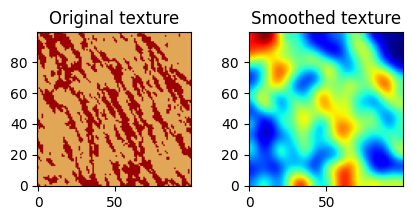

In [1]:
from pathlib import Path
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

import bitis as bt

from matplotlib import colors as mcolors

tex_cmap = mcolors.LinearSegmentedColormap.from_list(
    'fibrosis', [(0, 'white'),
                 (0.5, '#e2a858'),
                 (1, '#990102')])

df = bt.tissue_dataset()

# Filter the dataset to extract one specific texture that meets the criteria:
filtered_df = df[(df['Density'].between(0.3, 0.35)) &
                 (df['Elongation'] > 2.5)]

print(filtered_df.shape)
texture = filtered_df["Tissue Matrix"].iloc[1]

# 1 - healthy tissue, 2 - fibrosis
texture = np.where(texture == 0, 1, 2).astype(np.float32)

texture_smoothed = gaussian_filter(texture, sigma=5)

fig, axs = plt.subplots(1, 2, figsize=(5, 2))
axs[0].imshow(texture, cmap=tex_cmap, origin='lower', vmin=0, vmax=2)
axs[0].set_title('Original texture')
axs[1].imshow(texture_smoothed, cmap='jet', origin='lower')
axs[1].set_title('Smoothed texture')
plt.show()

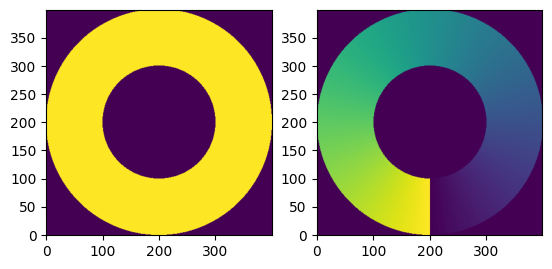

In [2]:
import numpy as np

size = 400
inner_radius = 100
outer_radius = 200

# Coordinates grid centered in the middle of the array
y, x = np.ogrid[:size, :size]
center = (size - 1) / 2
dist = np.sqrt((x - center)**2 + (y - center)**2)
# Coordinates relative to center
dx = x - center
dy = y - center

# Angle in radians (-pi to pi)
angles = np.arctan2(dy, dx)

# Optional: convert to degrees (0° to 360°)
angles_deg = (90 + np.degrees(angles)) % 360
angles_deg = np.round(angles_deg)

angle_map = np.zeros((size, size), dtype=np.float32)
angle_map[y, x] = angles_deg
angle_map = angle_map[:]

# Ring mask
ring_mask = (dist >= inner_radius) & (dist <= outer_radius)

# Example: array with 1s for ring, 0 elsewhere
arr = np.zeros((size, size), dtype=np.uint8)
arr[ring_mask] = 1

angle_map[~ring_mask] = 0

fig, axs = plt.subplots(ncols=2)
axs[0].imshow(arr, origin='lower')
axs[1].imshow(angle_map, origin='lower')
plt.show()

100%|██████████| 94248/94248 [00:11<00:00, 7857.55it/s]


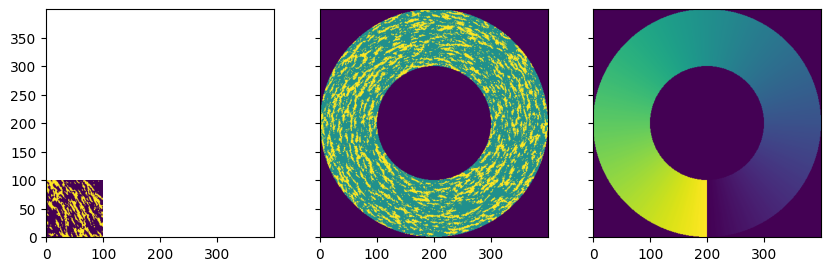

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

import bitis as bt


df = bt.tissue_dataset()

# Filter the dataset to extract one specific texture that meets the criteria:
filtered_df = df[(df['Density'].between(0.3, 0.35)) &
                 (df['Elongation'] > 2.5)]
texture = filtered_df["Tissue Matrix"].iloc[1]

# 1 - healthy tissue, 2 - fibrosis
texture = np.where(texture == 0, 1, 2)
training_image = texture.astype(np.float32)

max_known_pixels = 30
max_template_size = 40
min_template_size = 3
num_of_candidates = 1
min_known_pixels = 1

simulation_tex = np.zeros_like(angle_map, dtype=np.float32)
simulation = bt.Simulation()
simulation.path_builder = bt.RandomSimulationPathBuilder(simulation_tex,
                                                         tissue_mask=ring_mask)
simulation.template_builder = bt.AdaptiveTemplateBuilder(simulation_tex,
                                                         max_known_pixels,
                                                         max_template_size,
                                                         min_template_size)
simulation.template_matching = bt.RotatedImagesMatching(training_image,
                                                        angle_map,
                                                        base_angle=-60,
                                                        num_of_candidates=num_of_candidates,
                                                        min_known_pixels=min_known_pixels)
simulated_tex = simulation.run()

fig, ax = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
ax[0].imshow(training_image, origin='lower')
ax[1].imshow(simulated_tex, origin='lower')
ax[2].imshow(angle_map, origin='lower')
plt.show()


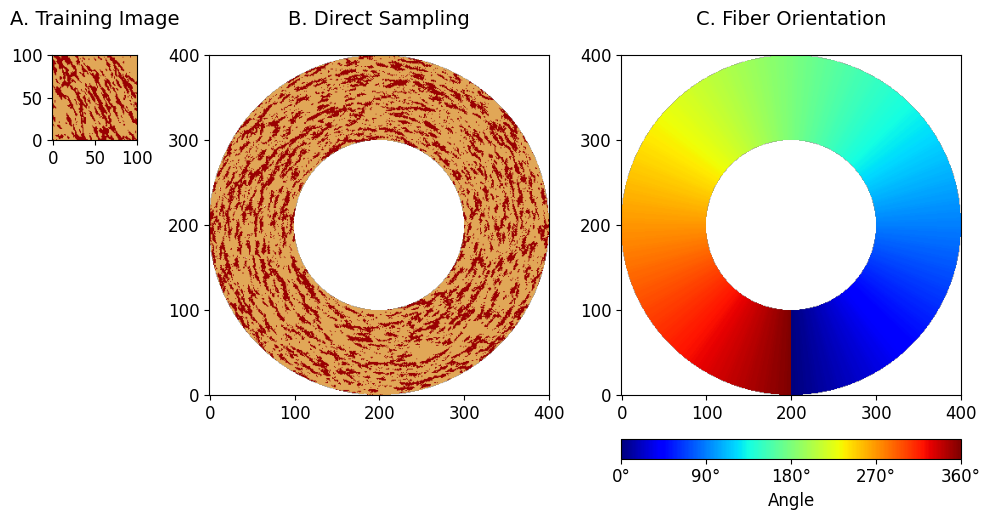

In [25]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

angle_map_ = np.ma.masked_array(angle_map, ~ring_mask)
simulated_tex_ = np.ma.masked_array(simulated_tex, ~ring_mask)

fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(10, 5.3),
                        width_ratios=[1, 4, 4], 
                        height_ratios=[1, 0.05])
axs[0, 0].imshow(training_image, vmin=0, vmax=2, cmap=tex_cmap, origin='lower')
axs[0, 1].imshow(simulated_tex_, vmin=0, vmax=2, cmap=tex_cmap, origin='lower')

axs[0, 2].imshow(angle_map_[:, :], origin='lower', cmap="jet")

cbar = plt.colorbar(axs[0, 2].images[0], cax=axs[1, 2],
                    orientation='horizontal')
cbar.ax.set_xticks(np.arange(0, 361, 90))
cbar.ax.set_xticklabels([f"{d}°" for d in np.arange(0, 361, 90)])
cbar.set_label('Angle', fontsize=12)

axs[0, 0].set_xticks(np.arange(0, 101, 50))
axs[0, 0].set_yticks(np.arange(0, 101, 50))

axs[0, 1].set_xticks(np.arange(0, 401, 100))
axs[0, 1].set_yticks(np.arange(0, 401, 100))
axs[0, 2].set_xticks(np.arange(0, 401, 100))
axs[0, 2].set_yticks(np.arange(0, 401, 100))

for ax in axs.flat:
    ax.set_anchor('NW')
    ax.tick_params(axis='both', which='major', labelsize=12)

axs[1, 0].axis('off')
axs[1, 1].axis('off')

axs[0, 0].set_title("A. Training Image\n", fontsize=14)
axs[0, 1].set_title("B. Direct Sampling\n", fontsize=14)
axs[0, 2].set_title("C. Fiber Orientation\n", fontsize=14)

plt.tight_layout()
plt.show()

In [26]:
fig.savefig("figure6.png", dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'Inset')

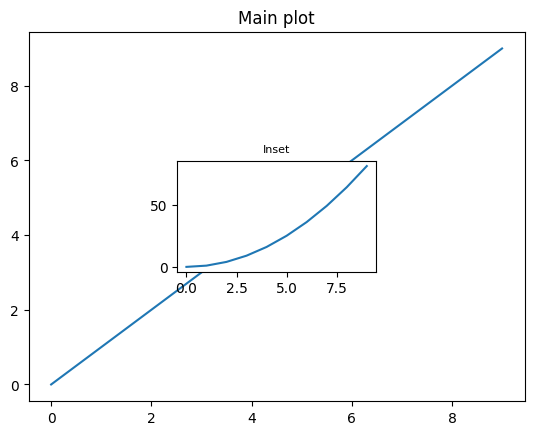

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(range(10), range(10))
ax.set_title("Main plot")

# Create inset: width=40%, height=30% of parent axes
ax_inset = inset_axes(ax, width="40%", height="30%", loc="center")
ax_inset.plot(range(10), [x**2 for x in range(10)])
ax_inset.set_title("Inset", fontsize=8)
